In [53]:

# import external libraries
import joblib
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import logging
from typing import Tuple

# import scipy libraries
from scipy.stats.mstats import winsorize

# import sklearn libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score, accuracy_score,log_loss, roc_curve,auc
from sklearn.decomposition import PCA

# lightgbm
%pip install lightgbm
import lightgbm as lgb
from lightgbm import log_evaluation, early_stopping

# xgboost
%pip install xgboost
import xgboost as xgb

# set global constants
GLOBAL = {
    'DATA_PATH':'diabetes.csv',
    'TARGET_VARIABLE':'Type',
    'RANDOM_STATE':10,
    'TEST_SIZE':0.2
}

# ignore warnings
warnings.filterwarnings('ignore')

# set logging configuration
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
# function to load the dataset
def load_data(file_path: str) -> pd.DataFrame:
    """Loads raw dataset from a CSV file."""
    if not os.path.exists(file_path):
        logger.error(f"File not found at: {file_path}")
        raise FileNotFoundError(f"Missing input data: {file_path}")

    logger.info(f"Loading data from {file_path}")

    df = sns.load_dataset('titanic')
    
    logger.info(f"Data shape: {df.shape}")
    return df

try:
    # call the function
    df = load_data(GLOBAL['DATA_PATH'])

    # create a copy of the df 
    df_copy = pd.DataFrame.copy(df)

except FileNotFoundError:
    print(f"Missing input data")




2026-06-20 10:07:58,238 - INFO - Loading data from diabetes.csv


2026-06-20 10:07:58,259 - INFO - Data shape: (891, 15)


In [55]:
# ===========================
# 1. Exploratory Data Analysis
# ===========================

def inspect_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Features of the dataset"""
    
    # print the column names
    print("---Columns---")
    print(df.columns)

    # print the shape of the data frame
    print("---Shape of df---")
    print(df.shape)

    # print the datatypes
    print("---Datatypes of columns---")
    print(df.dtypes)

    # print the missing values
    print("--- Missing Values ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # imputation of missing values
    print("---Imputation of Missing Values---")
    for col in df.columns[:-1]:
        if df[col].dtype != 'object' and df[col].dtype != 'category':
            df[col].fillna(df[col].mean(), inplace=True)
        if df[col].dtype == 'object' or df[col].dtype == 'category':
            df[col].fillna(df[col].mode()[0], inplace=True)

    # print the unique values
    print("Unique Values of columns")
    for x in df.columns:
        print(df[x].unique())

    # print the statistical values
    print("\n--- Summary Statistics ---")
    print(df.describe())

    # print the details about the columns
    print("\n---Details of the columns---")
    print(df.info())

    # drop redundant columns
    print("\n---Drop Redundant columns---")
    
    df.drop(columns=['alive','class','adult_male','deck','embark_town'],inplace=True)
    print(df.columns)
    return df

df_copy = inspect_dataframe(df_copy)


---Columns---
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
---Shape of df---
(891, 15)
---Datatypes of columns---
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
--- Missing Values ---
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
---Imputation of Missing Values---
Unique Values of columns
[0 1]
[3 1 2]
['male' 'female']
[22.         38.         26.         35.         29.69911765 54.
  2.         27.         14.          4.         58.         20.
 39.         55.         31.      

Columns in DataFrame: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone']


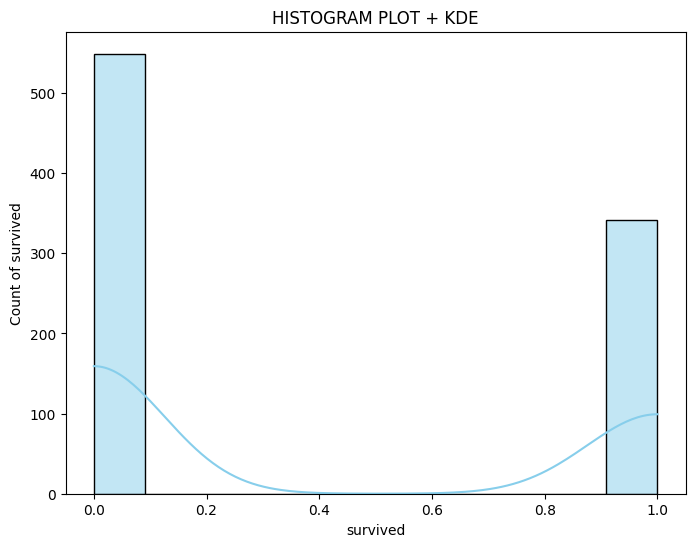

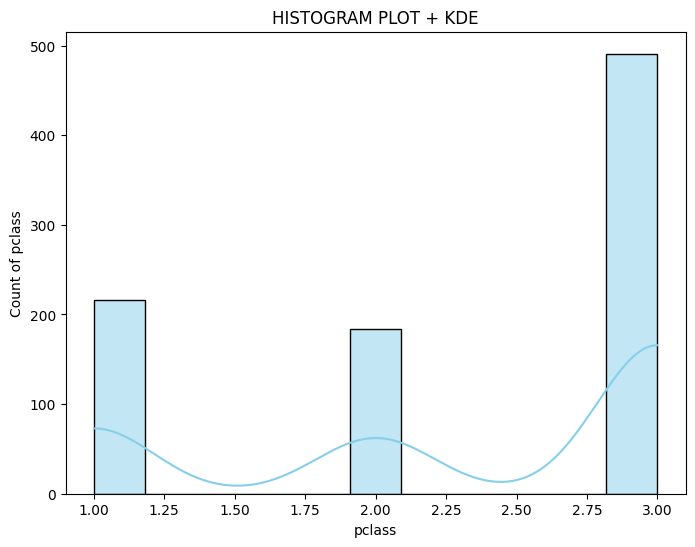

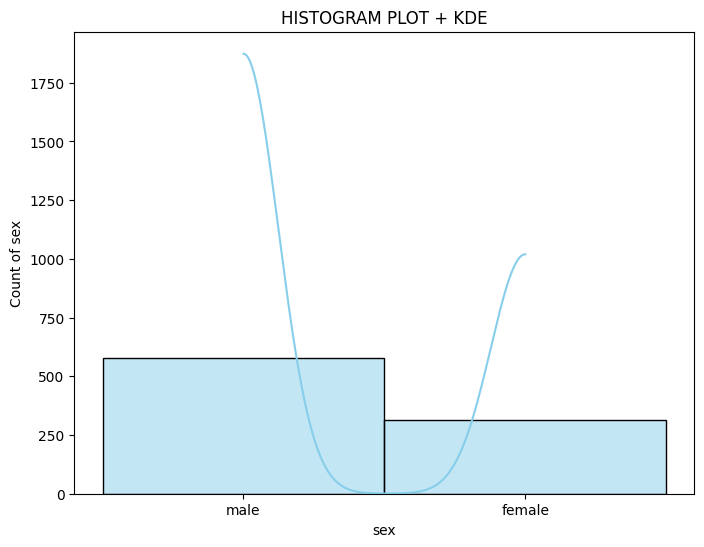

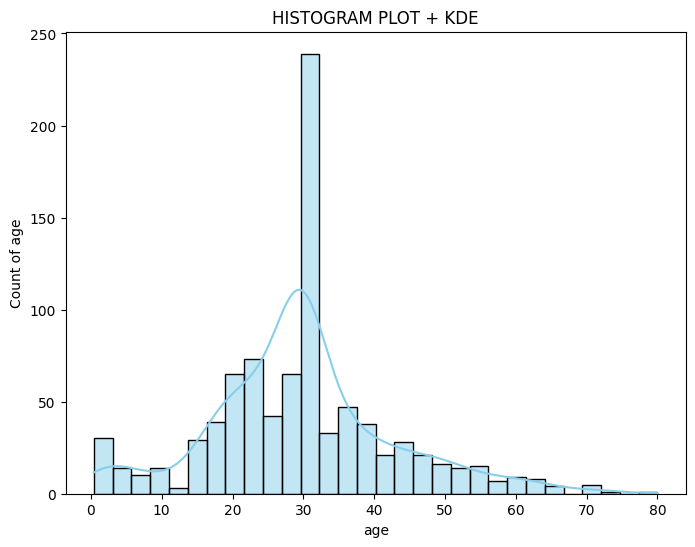

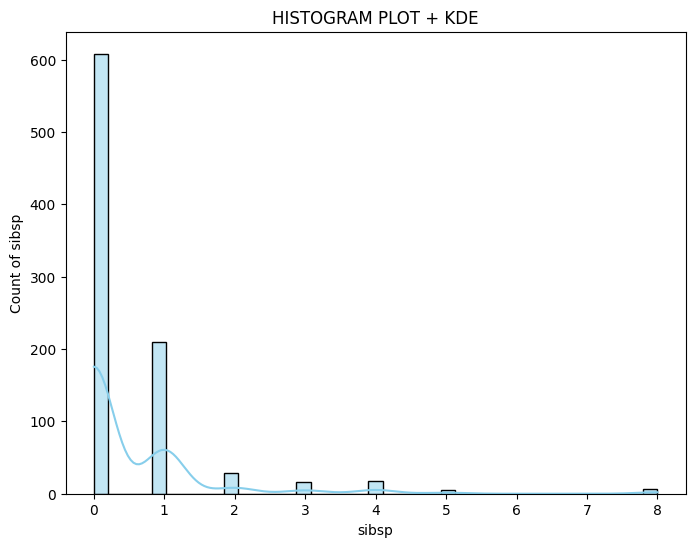

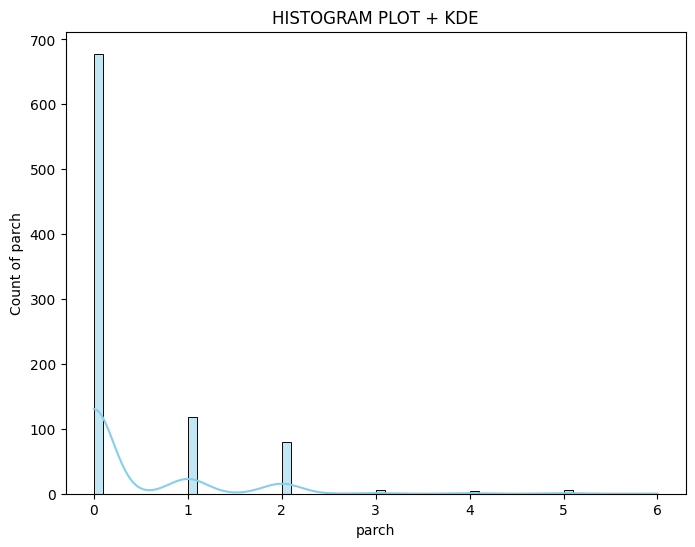

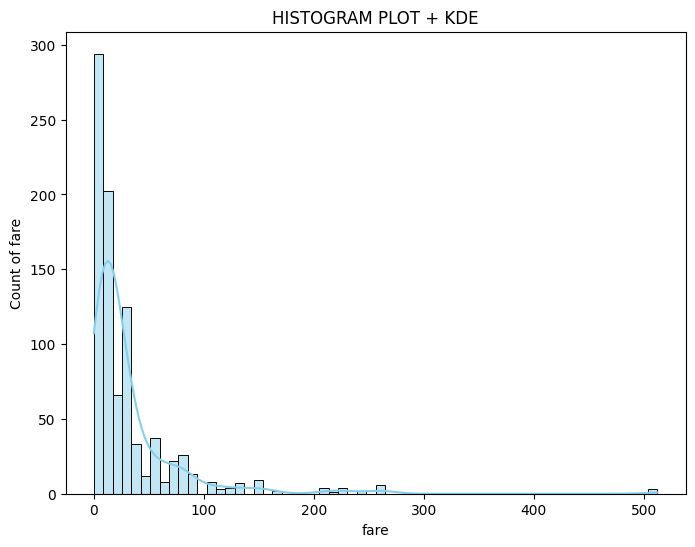

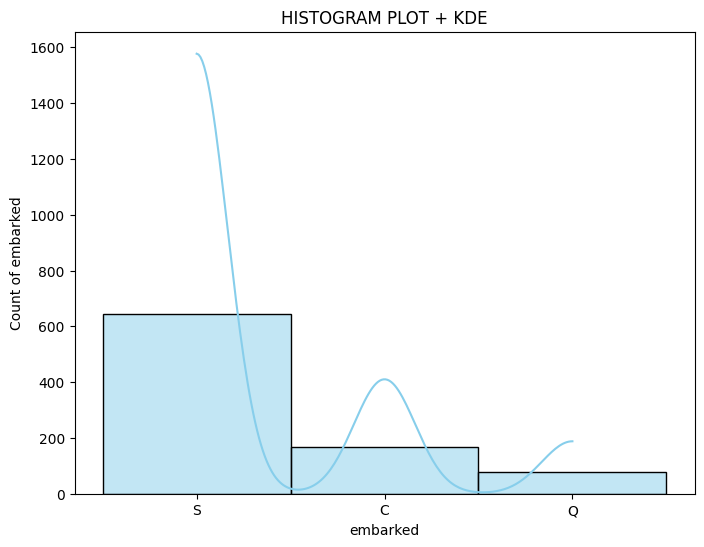

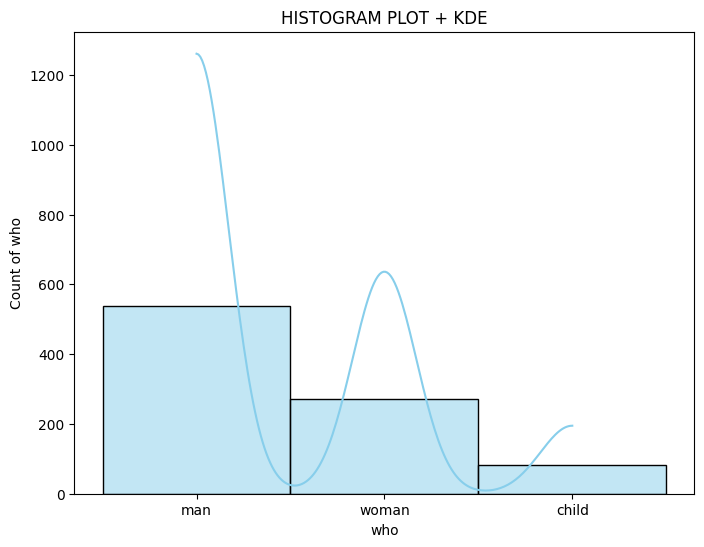

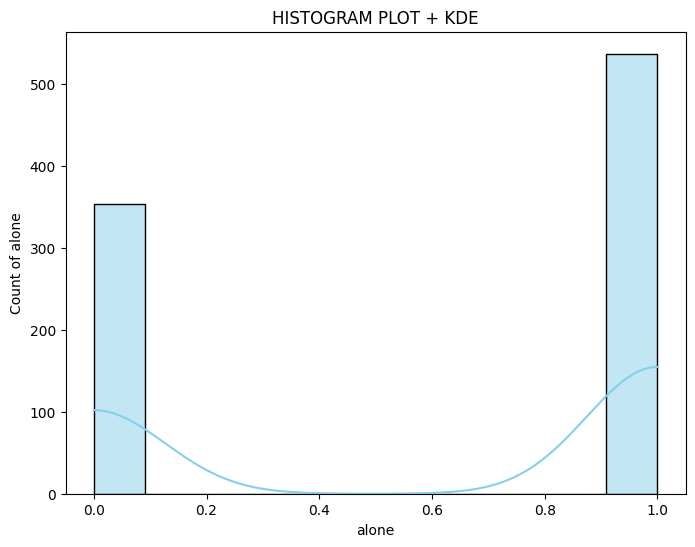

---Before Winsorization---


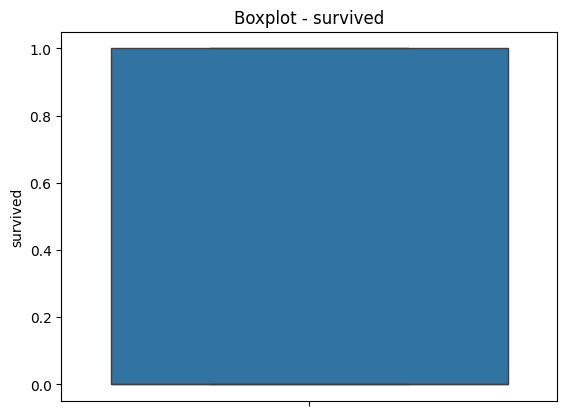

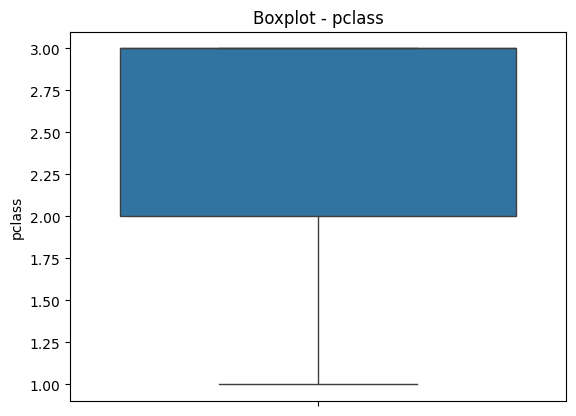

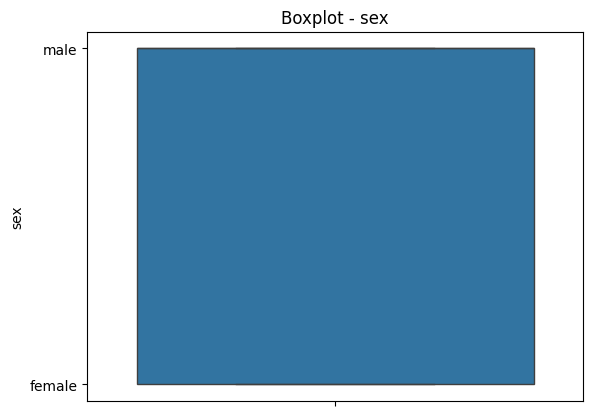

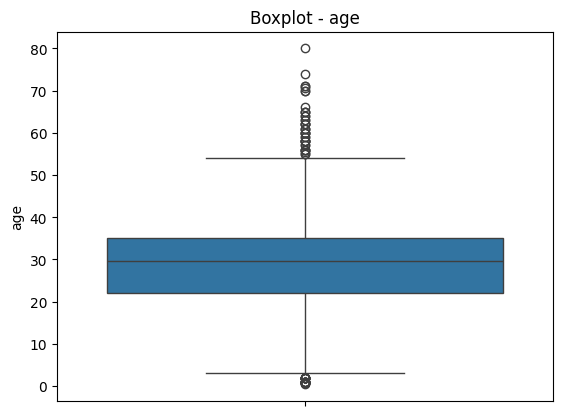

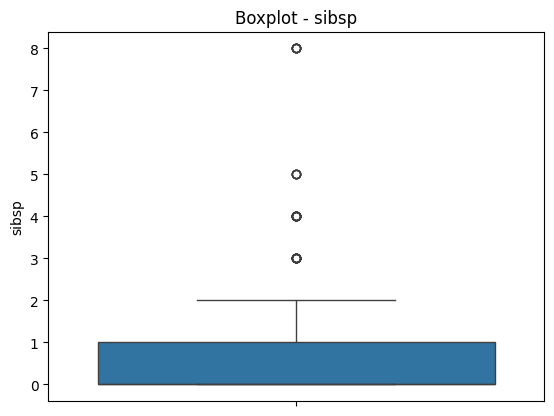

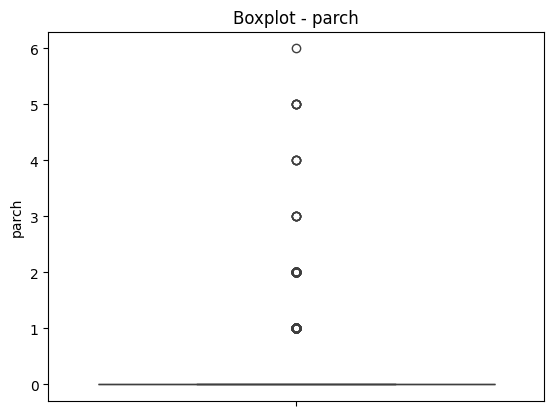

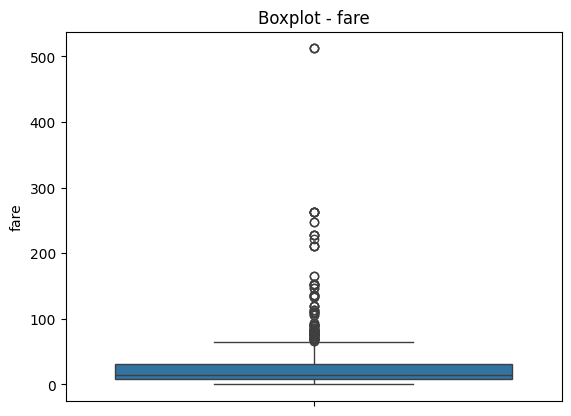

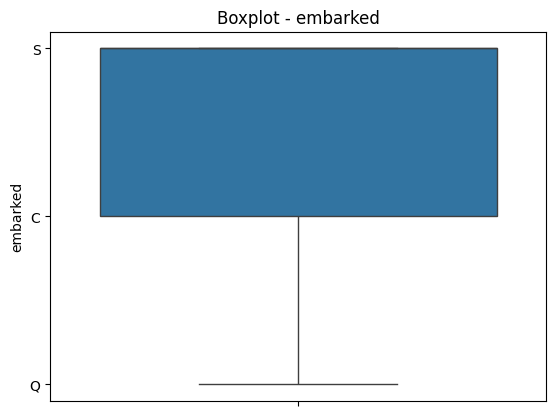

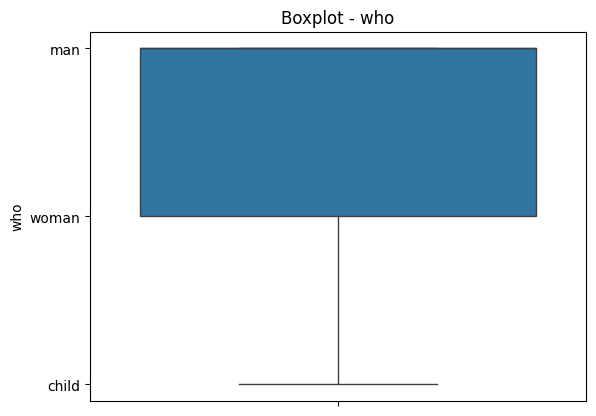

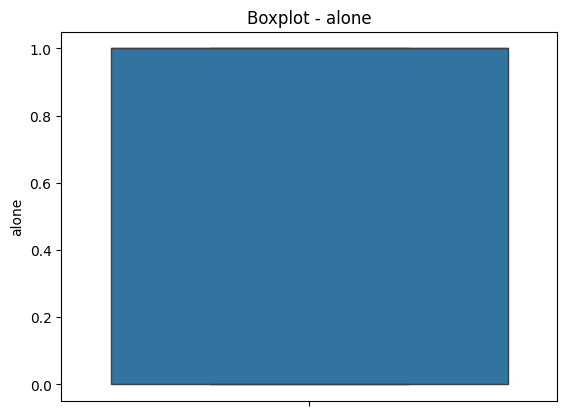

---After Winsorization---


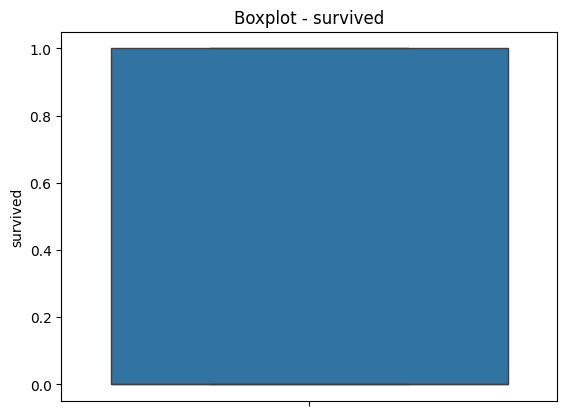

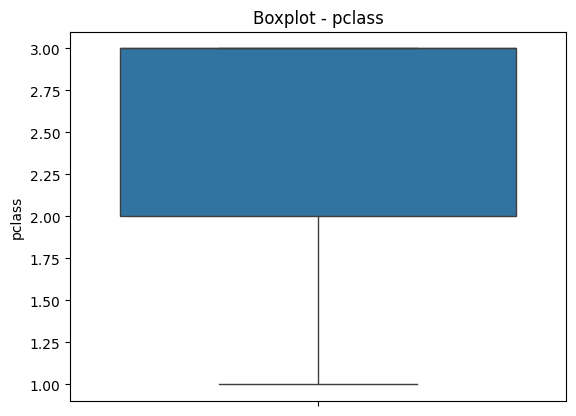

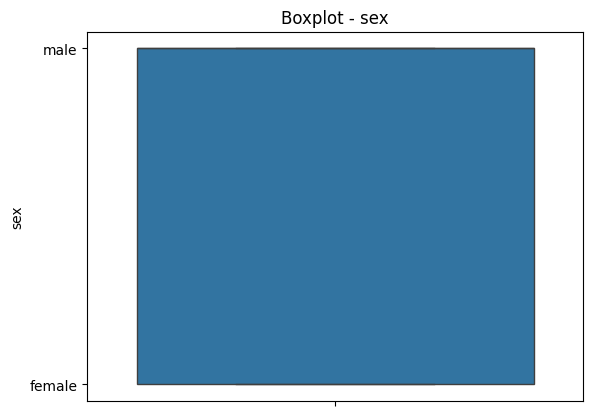

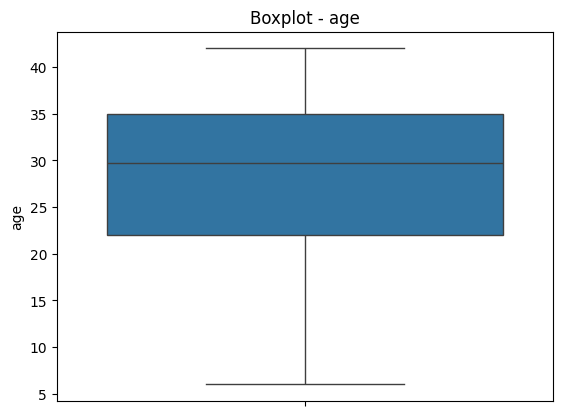

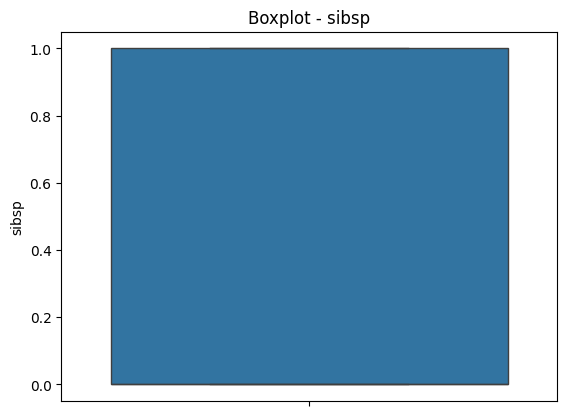

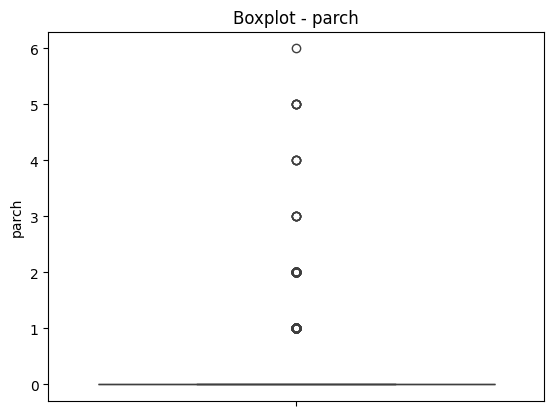

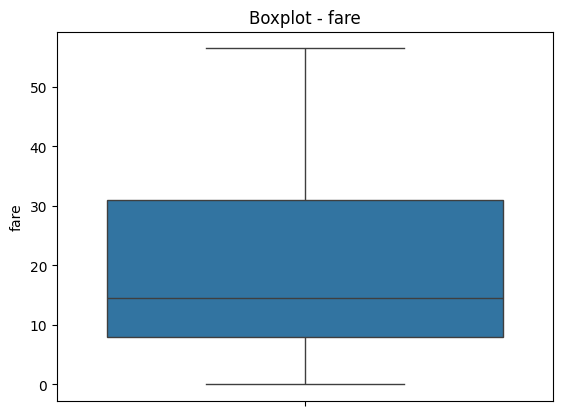

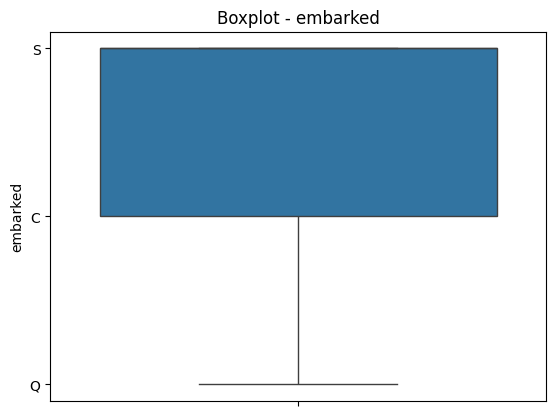

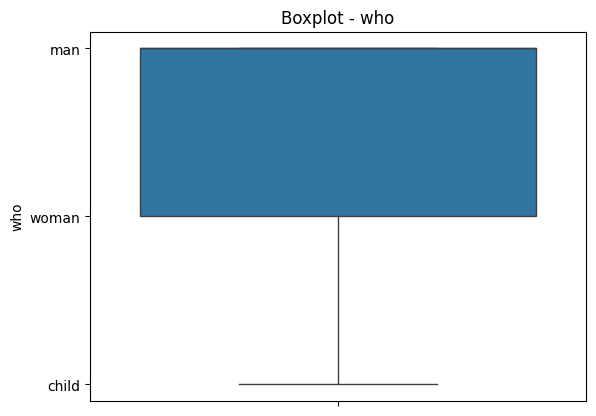

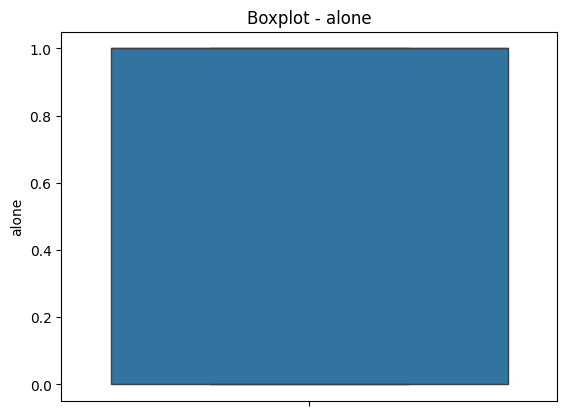

In [56]:
# ===========================
# 2. Data Visualization
# ===========================
def eda_visualizations(df_copy: pd.DataFrame) -> None:
    """INCLUDES HISTOGRAM CHART, BOXPLOT AND WINSORIZATION FOR REMOVING OUTLIERS."""

    df_copy = pd.DataFrame(df_copy)

    print("Columns in DataFrame:", df_copy.columns.tolist())


    # Histogram chart
    for col in df_copy.columns:
        plt.figure(figsize = (8,6))
        sns.histplot(df_copy,x = col,kde = True,color = "skyblue")
        plt.title("HISTOGRAM PLOT + KDE")
        plt.xlabel(f"{col}")
        plt.ylabel(f"Count of {col}")
        plt.show()

    # Boxplot
    print("---Before Winsorization---")
    for col in df_copy.columns:   
        plt.Figure(figsize=(8,6))
        sns.boxplot(data = df_copy,y = col)
        plt.title(f"Boxplot - {col}")
        plt.show()

    # winsorize the data to remove outliers.
    for col in ['fare','sibsp']:
        df_copy[col] = winsorize(df_copy[col], limits=[0,0.15])
     
    for col in ['age']:
        df_copy[col] = winsorize(df_copy[col],limits=[0.05,0.15])

    # show the boxplot values after winsorization
    print("---After Winsorization---")
    for col in df_copy.columns:   
        plt.Figure(figsize=(8,6))
        sns.boxplot(data = df_copy,y = col)
        plt.title(f"Boxplot - {col}")
        plt.show()

eda_visualizations(df_copy)

In [57]:
# ===================================
# 3. Data Preprocessing
# ===================================

def data_preprocessing() -> Tuple[np.array, np.array]:
    """PREPROCESS THE DATA BY REMOVING NULL VALUES, ENCODING CATEGORICAL COLUMNS AND SCALING THE DATA."""

    # missing values
    print("---Check for Missing Values---")
    columns_with_missing_values = []
    for col in df_copy.columns:
        if df_copy[col].isnull().sum()>0:
            columns_with_missing_values.append(col)
    if len(columns_with_missing_values)>0:
        print("Missing Values: ")
        for col in df_copy[columns_with_missing_values].columns:
            print(df_copy[col],": ", df_copy[col].isnull().sum())
            if df_copy[col].dtype != 'object' and df_copy[col].dtype != 'category':
                df_copy[col].fillna(df_copy[col].mean(),inplace=True)
            if df_copy[col].dtype == 'object' :
                df_copy[col].fillna(df_copy[col].mode(),inplace=True)
    else:
        print("No missing values found in the dataset.")

    # datatypes of columns
    print("---Datatype of columns---")
    categorical_cols = []
    for col in df_copy.columns:
        if df_copy[col].dtype=='object' or df_copy[col].dtype=='category':
            categorical_cols.append(col)
            
    # show the categorical columns if present.    
    if len(categorical_cols)>0:
        print("Categorical Columns : ",categorical_cols)
    else:
        print("No categorical variables found. Encoding Not needed.")

    # label encoding
    # Dictionary to hold the fitted encoder objects
    saved_encoders = {}

    # 3. Fit, transform, and store each encoder
    for col in categorical_cols:
        # Initialize a clean encoder instance
        le = LabelEncoder()
    
        # Fit on the column and transform the original data in-place
        df_copy[col] = le.fit_transform(df_copy[col].astype(str))
    
        # Save the FITTED OBJECT into our dictionary
        saved_encoders[col] = le
        print(f"Encoded '{col}'. Classes mapped: {list(le.classes_)}")

    # scaling of features
    print("---Feature Scaling---")
    X = df_copy.values[:,1:]
    Y = df_copy.values[:,0]

    # scale the values
    scaler = StandardScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    print("Scaled Features : \n",X)
    
    # Principal Component Analysis
    # Apply PCA to keep 95% of variance
    pca = PCA(n_components=0.95, random_state=GLOBAL['RANDOM_STATE'])
    X_reduced = pca.fit_transform(X)
    print(f"Original features: {X.shape[1]}, Reduced features: {X_reduced.shape[1]}")

    return X,Y, scaler, X_reduced, saved_encoders
# call the function
X,Y, scaler,X_reduced, saved_encoders = data_preprocessing()

    


---Check for Missing Values---
No missing values found in the dataset.
---Datatype of columns---
Categorical Columns :  ['sex', 'embarked', 'who']
Encoded 'sex'. Classes mapped: ['female', 'male']
Encoded 'embarked'. Classes mapped: ['C', 'Q', 'S']
Encoded 'who'. Classes mapped: ['child', 'man', 'woman']
---Feature Scaling---
Scaled Features : 
 [[ 0.82737724  0.73769513 -0.5924806  ...  0.58595414 -0.3552422
  -1.2316449 ]
 [-1.56610693 -1.35557354  0.63878901 ... -1.9423032   1.32837909
  -1.2316449 ]
 [ 0.82737724 -1.35557354 -0.2846632  ...  0.58595414  1.32837909
   0.81192233]
 ...
 [ 0.82737724 -1.35557354  0.         ...  0.58595414  1.32837909
  -1.2316449 ]
 [-1.56610693  0.73769513 -0.2846632  ... -1.9423032  -0.3552422
   0.81192233]
 [ 0.82737724  0.73769513  0.17706291 ... -0.67817453 -0.3552422
   0.81192233]]
Original features: 9, Reduced features: 8


---LightGBM---
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[343]	valid_0's binary_logloss: 0.348969
LightGBM - Training Accuracy: 0.87
LightGBM - Test Accuracy: 0.86
LightGBM - Training Loss: 0.31
LightGBM - Test Loss: 0.35

---XGBoost---
XGBoost - Training Accuracy: 0.97
XGBoost - Test Accuracy: 0.82
XGBoost - Training Loss: 0.11
XGBoost - Test Loss: 0.47
LG Boosting AUC: 0.9119106699751861


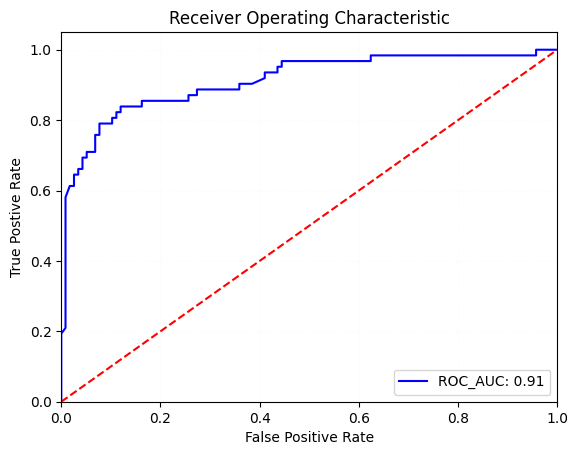

XG Boost AUC: 0.8734491315136477


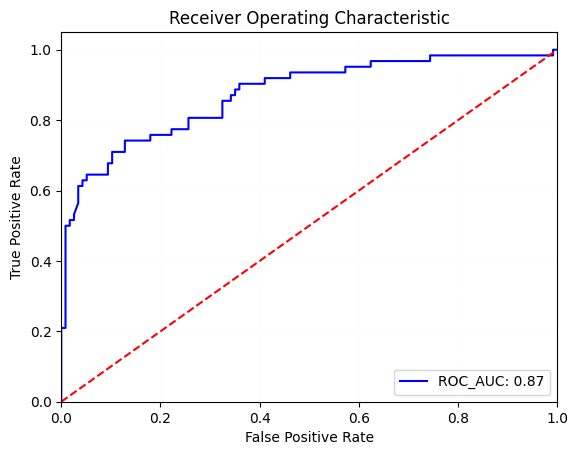

In [58]:

def train_test_model(X: np.array, Y: np.array):
    # Ensure targets are structured properly as flat integers
    Y = Y.astype(int).flatten()
    
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, random_state=GLOBAL['RANDOM_STATE'], test_size=GLOBAL['TEST_SIZE']
    )

    print("---LightGBM---")
    train_data = lgb.Dataset(X_train, label=Y_train)
    valid_data = lgb.Dataset(X_test, label=Y_test, reference=train_data)

    # Set parameters
    params = {
        'objective': 'binary',
        'learning_rate': 0.01,
        'metric': 'binary_logloss',
        'num_leaves': 31,
        'verbose': -1
    }
    
    lgb_model = lgb.train(
        params,
        train_data,
        num_boost_round=5000,
        valid_sets=[valid_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=10),
            lgb.log_evaluation(period=0)  # Set period=10 to print every 10 rounds
        ]
    )

    # LightGBM Predictions (Returns probabilities)
    y_pred_train_lgb_proba = lgb_model.predict(X_train)
    y_pred_test_lgb_proba = lgb_model.predict(X_test)
    
    y_pred_train_lgb_class = (y_pred_train_lgb_proba > 0.5).astype(int)
    y_pred_test_lgb_class = (y_pred_test_lgb_proba > 0.5).astype(int)

    # Evaluate LightGBM
    training_accuracy_lgb = accuracy_score(Y_train, y_pred_train_lgb_class)
    test_accuracy_lgb = accuracy_score(Y_test, y_pred_test_lgb_class)
    training_loss_lgb = log_loss(Y_train, y_pred_train_lgb_proba)
    test_loss_lgb = log_loss(Y_test, y_pred_test_lgb_proba)

    print("LightGBM - Training Accuracy:", np.round(training_accuracy_lgb, 2))
    print("LightGBM - Test Accuracy:", np.round(test_accuracy_lgb, 2))
    print("LightGBM - Training Loss:", np.round(training_loss_lgb, 2))
    print("LightGBM - Test Loss:", np.round(test_loss_lgb, 2))

    # XG Boosting
    print("\n---XGBoost---")
    # Create and train the XGBoost model
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
    xgb_model.fit(X_train, Y_train)

    # Get both binary classes (for accuracy) AND probabilities (for log_loss)
    y_pred_train_xgb_class = xgb_model.predict(X_train)
    y_pred_test_xgb_class = xgb_model.predict(X_test)
    
    # .predict_proba() returns [prob_class_0, prob_class_1]. 
    y_pred_train_xgb_proba = xgb_model.predict_proba(X_train)[:, 1]
    y_pred_test_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

    # Evaluate XGBoost safely
    training_accuracy_xgb = accuracy_score(Y_train, y_pred_train_xgb_class)
    test_accuracy_xgb = accuracy_score(Y_test, y_pred_test_xgb_class)
    
    # FIX: Passing the continuous probabilities into the log loss functions
    training_loss_xgb = log_loss(Y_train, y_pred_train_xgb_proba)
    test_loss_xgb = log_loss(Y_test, y_pred_test_xgb_proba)

    # print the results
    print("XGBoost - Training Accuracy:", np.round(training_accuracy_xgb, 2))
    print("XGBoost - Test Accuracy:", np.round(test_accuracy_xgb, 2))
    print("XGBoost - Training Loss:", np.round(training_loss_xgb, 2))
    print("XGBoost - Test Loss:", np.round(test_loss_xgb, 2))

    # LGB Classifier
    # visualize the metrics
    fpr, tpr, _ = roc_curve(Y_test,y_pred_test_lgb_proba)
    roc_auc = auc(fpr,tpr)
    print(f"LG Boosting AUC: {roc_auc}")

    # ROC Curve
    plt.title("Receiver Operating Characteristic")
    plt.plot(fpr,tpr,"b",label = f"ROC_AUC: {roc_auc:.2f}")
    plt.legend(loc = "lower right")
    plt.plot([0,1],[0,1],"r--")
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Postive Rate")
    plt.grid(True,linestyle = ":",alpha=0.06)
    plt.show()

    # XGB Classifier
    # visualize the metrics
    fpr, tpr , _ = roc_curve(Y_test, y_pred_test_xgb_proba)
    roc_auc = auc(fpr,tpr)
    print(f"XG Boost AUC: {roc_auc}")

    # ROC Curve
    plt.title("Receiver Operating Characteristic")
    plt.plot(fpr,tpr,"b",label =f"ROC_AUC: {roc_auc:.2f}")
    plt.legend(loc = "lower right")
    plt.plot([0,1],[0,1],"r--")
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, linestyle=":",alpha=0.06)
    plt.show()

    return xgb_model, lgb_model

# Run the function
xgb_model, lgb_model = train_test_model(X, Y)

In [59]:
# A brief report summarizing the comparative analysis results and practical implications.
# --> 1. LGB Model - It has accuracy of about 91% which is excellent.
#                   - It obtains True Positive Rate of 0.6 while keeping the False Positive Rate very low.
#                   - LGB Model performs better than the XGB model because of the above mentioned reason
# --> 2. XGB Model - It has accuracy of about 89% which is also good.
#                   - It aslo obtains True Postive Rate of 0.35 while keeping the false positive rate very low, 
#                       but the LGB model has slighly better performance than the XGB model.

In [60]:
joblib.dump(xgb_model,"xgb_model.pkl")
joblib.dump(lgb_model,"lgb_model.pkl")

with open("le_embarked.pkl", "wb") as f:
    joblib.dump(saved_encoders['embarked'], f)

with open("le_who.pkl", "wb") as f:
    joblib.dump(saved_encoders['who'], f)

with open("le_sex.pkl", "wb") as f:
    joblib.dump(saved_encoders['sex'], f)
